# `hw4`: Heart failure prediction

In [2]:
# Fill in this cell with your personal details:
# - Name: Dutailly Alexandre
# - Student ID: S195855
# - Email: alexandre.dutailly@student.uliege.be

Deadline: **Friday, December 20, 23:59**.

Instructions:
- Submit your completed notebook on your personal Github repository created when accepting the assignment.
- All cells must be executable and their outputs should not be erased before submission.
- This case study must be carried out alone. You are not allowed to discuss or collaborate with other students.
- In January, you will have to explain and defend your solution during a 30-minute oral exam.
- The take-home exam (including its defense in January) will account for 50% of the final grade.

Comments:
- Solve the case study below by following the Bayesian workflow as best as possible.
- Follow the data visualization principles to make your plots effective and readable.
- Make the best use of the Python scientific ecosystem.
- Feel free to add comments when necessary.

# Introduction

Cardiovascular diseases are the number 1 cause of death globally, taking an estimated 17 million lives each year. In this case study, you will explore a dataset of health records of 299 patients who had heart failure, collected by [Chicco and Jurman](https://bmcmedinformdecismak.biomedcentral.com/articles/10.1186/s12911-020-1023-5) (2020). Each patient profile includes 13 features based on their clinical and physical conditions. Your task is to analyze this dataset to understand which features correlate most strongly with heart failure.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from scipy.stats import uniform, norm, beta as beta_dist
from scipy.optimize import minimize
from scipy.stats import skew, kurtosis

import seaborn as sns
import corner
import missingno as msno 
import emcee

# Data exploration

<div class="alert alert-success">
    
**Q1**. Load the `heart.csv` dataset into a data frame.
    
</div>

In [4]:
heart_df = pd.read_csv('heart.csv')


<div class="alert alert-success">
    
**Q2**. Explore the dataset and report relevant insights. 

</div>

Information about the dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory u

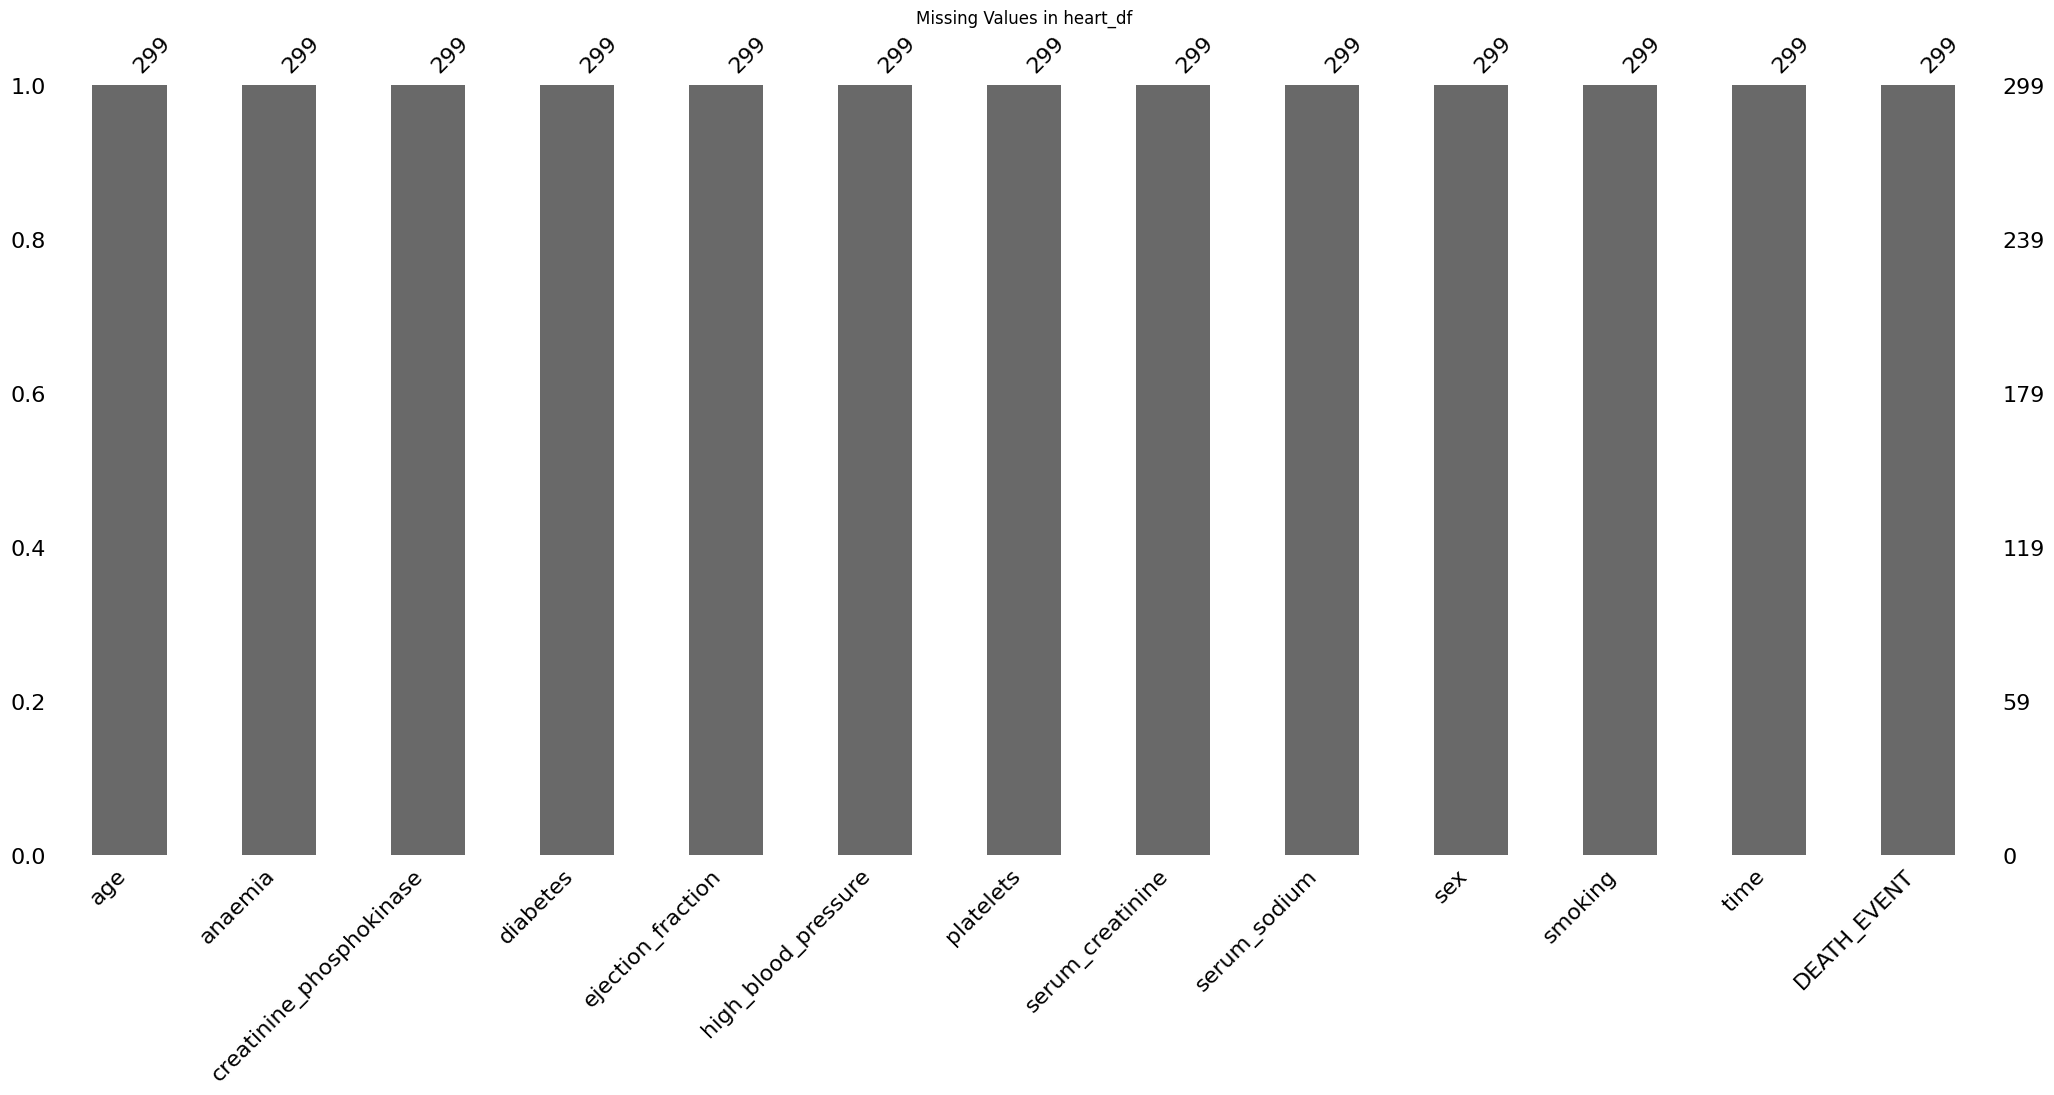

In [5]:

print("Information about the dataset :")
print(heart_df.info())
print("\nDescriptive statistics :")
print(heart_df.describe())

triple_risque = heart_df[
    (heart_df['smoking'] == 1) &
    (heart_df['high_blood_pressure'] == 1) &
    (heart_df['diabetes'] == 1)
]
print(f"\nNumber of patients with smoking, high blood pressure and diabetes: {len(triple_risque)}")

double_risque = heart_df[
    (heart_df['smoking'] == 1) &
    (heart_df['high_blood_pressure'] == 1)
]
nb_double_risque = len(double_risque)
print(f"\nNumber of patients with both smoking and high blood pressure: {nb_double_risque}")


hbp_count = len(heart_df[heart_df['high_blood_pressure'] == 1])
death_hbp_count = len(heart_df[(heart_df['high_blood_pressure'] == 1) & (heart_df['DEATH_EVENT'] == 1)])
print(f"high blood pressure: {hbp_count} and the ratio: {death_hbp_count / hbp_count}")
smoking_count = len(heart_df[heart_df['smoking'] == 1])
death_smoker_count = len(heart_df[(heart_df['smoking'] == 1) & (heart_df['DEATH_EVENT'] == 1)])
print(f"smoking: {smoking_count} and the ratio: {death_smoker_count / smoking_count}")


plt.figure(figsize=(10, 4))
msno.bar(heart_df)
plt.title("Missing Values in heart_df")
plt.show()





Thanks to the statistical data displayed, we can see that we have a sample of people over 40 years old with an average age of 80, and a majority of men. This corresponds to part of the ageing population. 

We can see that a large proportion have problems with diabetes, high blood pressure or smoking, representing 41.80%, 35.11% and 32.10% respectively. We also know that 11 people have all three, 30 who smoke and have blood problems.
We can also see that the mortality rate is 32.10% in this study.However, we can see that there is a higher mortality rate among people with blood pressure problems (37.14%) compared to the average and among smokers (31.25%).

In addition, with `missingno`, we can ensure that the dataset used is complete and that no values are missing for the 299 patients analysed.

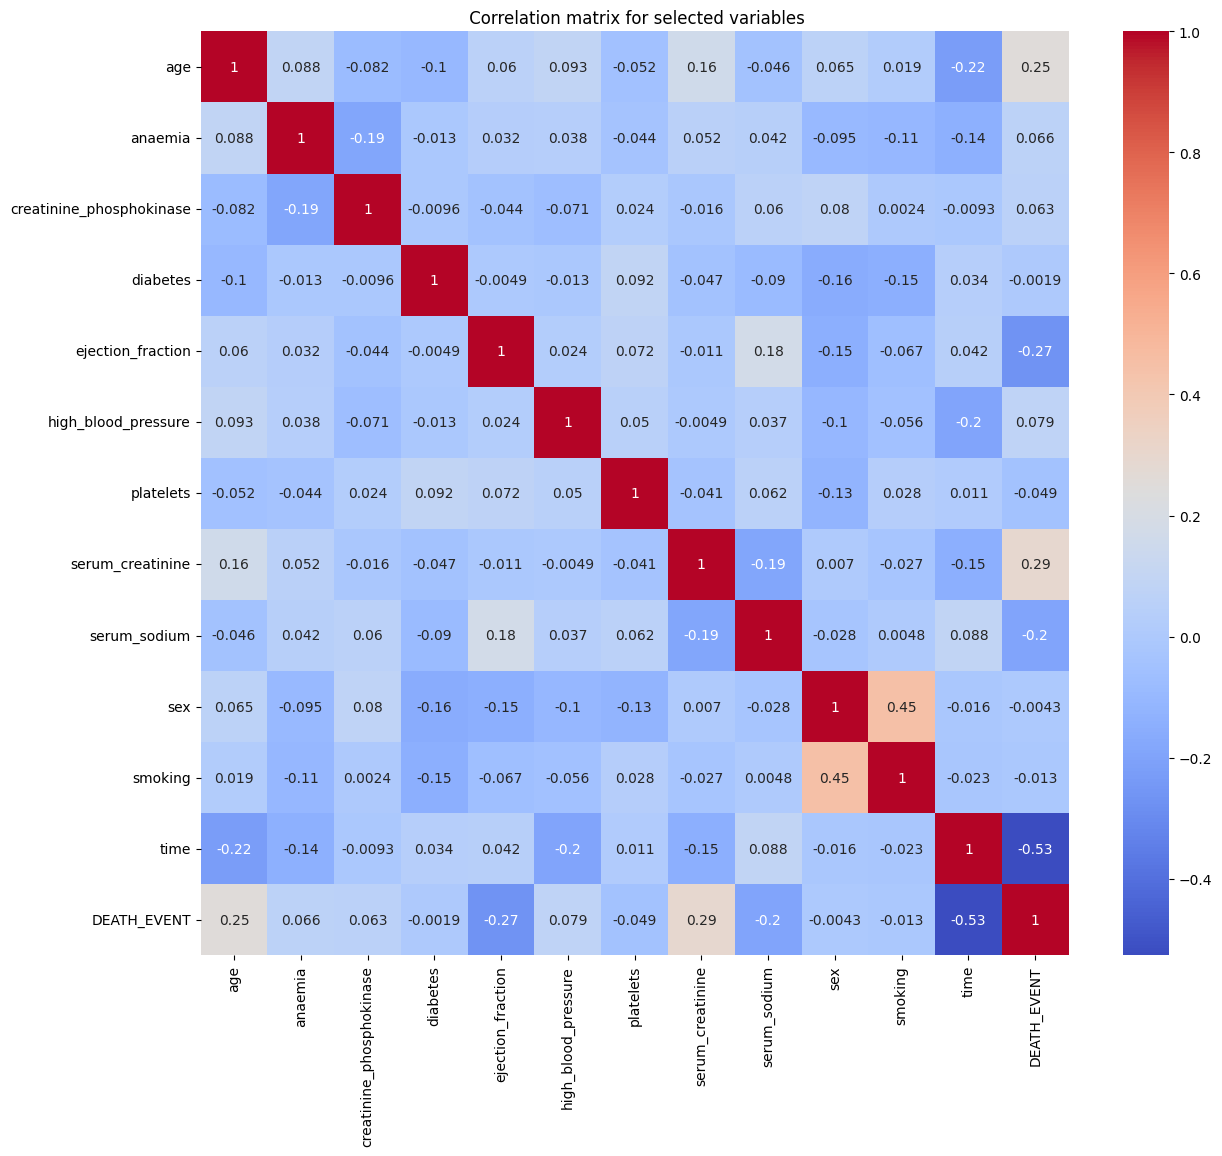

Variables most positively correlated with DEATH_EVENT :
serum_creatinine            0.294278
age                         0.253729
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
diabetes                   -0.001943
Name: DEATH_EVENT, dtype: float64

Variables most negatively correlated with DEATH_EVENT :
sex                 -0.004316
smoking             -0.012623
platelets           -0.049139
serum_sodium        -0.195204
ejection_fraction   -0.268603
time                -0.526964
Name: DEATH_EVENT, dtype: float64


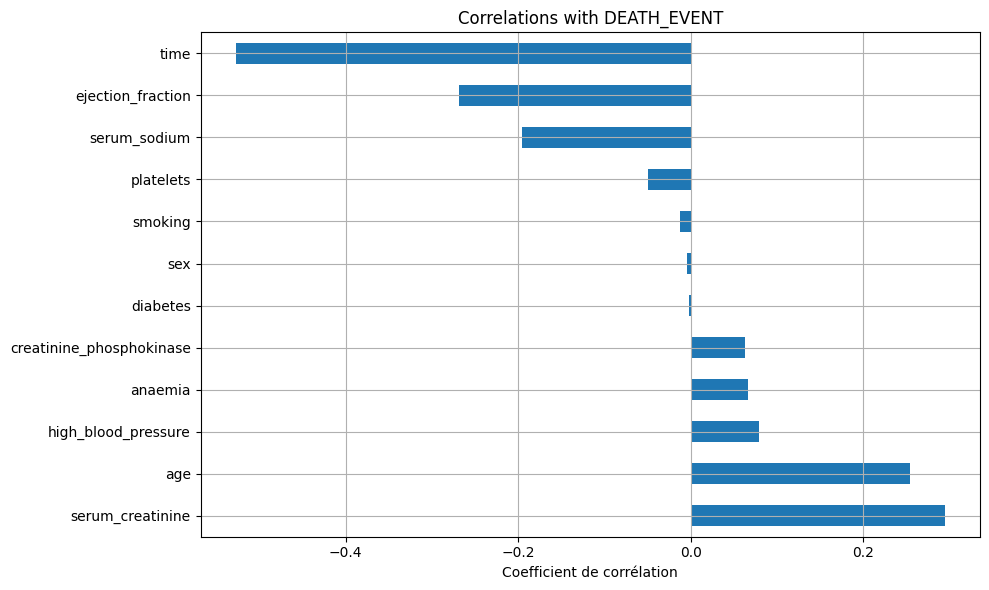

In [6]:

corr_mat = heart_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm')
plt.title(" Correlation matrix for selected variables")
plt.show()
correlations_with_death = corr_mat["DEATH_EVENT"].drop("DEATH_EVENT").sort_values(ascending=False)
print("Variables most positively correlated with DEATH_EVENT :")
print(correlations_with_death.head(6))

print("\nVariables most negatively correlated with DEATH_EVENT :")
print(correlations_with_death.tail(6))
plt.figure(figsize=(10,6))
correlations_with_death.plot(kind='barh')
plt.title("Correlations with DEATH_EVENT")
plt.xlabel("Coefficient de corrélation")
plt.grid(True)
plt.tight_layout()
plt.show()

Referring to the correlation matrix, we note that the variable most strongly correlated with mortality is `serum_creatinine`, which may indicate, among other things, that patients are suffering from kidney failure because their kidneys do not have time to filter the blood properly. There is a positive relationship, which may lead to a higher risk of death as the value increases. We observe the same type of relationship with `age`, which also appears to be positively correlated with mortality, which is not surprising. Older patients are more likely to die in this study. Certain conditions such as high blood pressure or anaemia also show a positive, albeit more moderate, association with mortality. 

Conversely, some variables show a negative correlation with mortality. This is particularly the case for the variable `time`, which represents the length of time spent in hospital. The fact that it is negatively correlated with `DEATH_EVENT` simply means that patients who remained alive were logically observed for longer. It is therefore not a risk factor in itself, but rather a consequence of someone's survival. A negative correlation is also observed for `ejection_fraction` and `serum_sodium`, which are relatively large.

If we look at the variables (`smoking` and `high_blood_pressure`) used in the questions below, we see that they are not strongly correlated with DEATH_EVENT. However, we can say that people who smoke in this study are slightly more likely to survive, and conversely, people with blood pressure problems are slightly more likely to die.

### Sources of information

- https://en.wikipedia.org/wiki/Creatinine 

- https://en.wikipedia.org/wiki/Ejection_fraction

- https://pmc.ncbi.nlm.nih.gov/articles/PMC5385798/


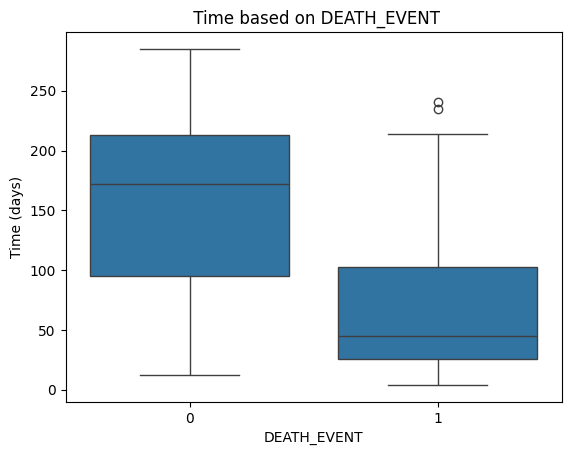

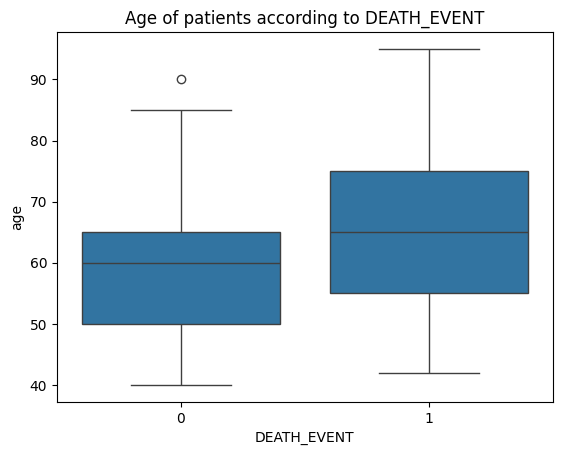

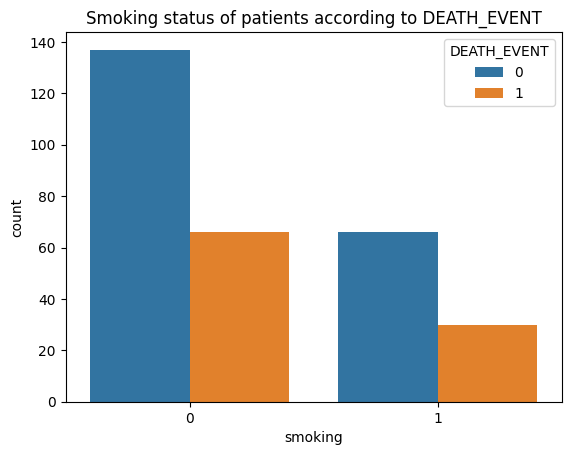

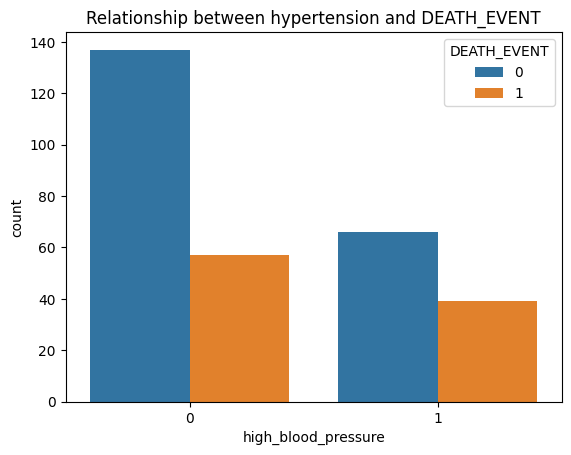

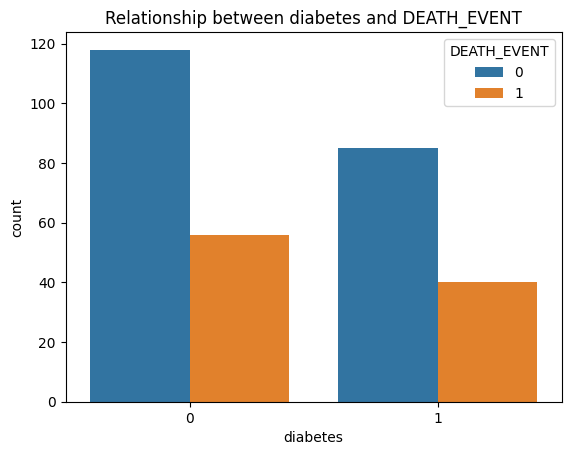

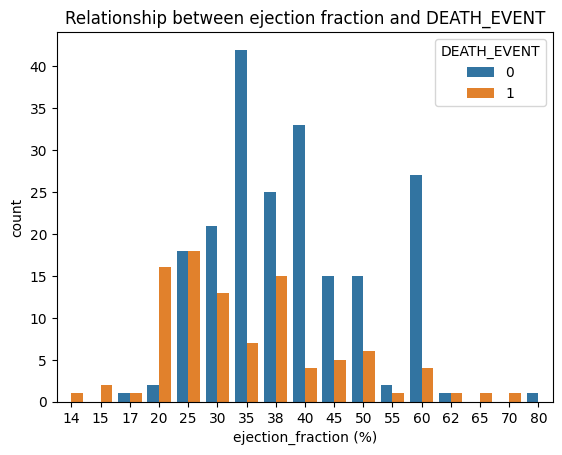

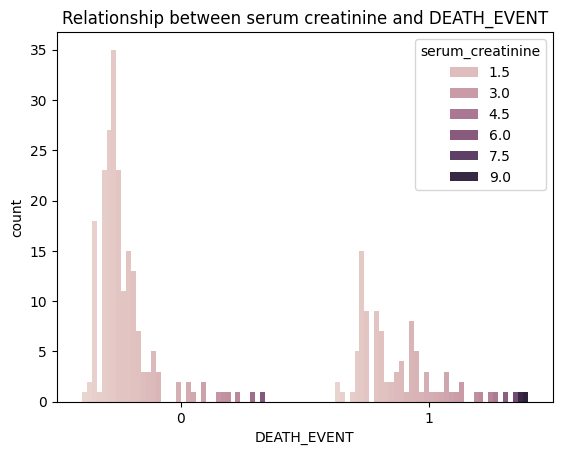

In [7]:
sns.boxplot(x='DEATH_EVENT', y='time', data=heart_df)
plt.title(" Time based on DEATH_EVENT")
plt.xlabel("DEATH_EVENT")
plt.ylabel("Time (days)")
plt.show()

sns.boxplot(x='DEATH_EVENT', y='age', data=heart_df)
plt.title("Age of patients according to DEATH_EVENT")
plt.show()

sns.countplot(x='smoking', hue='DEATH_EVENT', data=heart_df)
plt.title("Smoking status of patients according to DEATH_EVENT")
plt.ylabel("count")
plt.xlabel("smoking")
plt.show()

sns.countplot(x='high_blood_pressure', hue='DEATH_EVENT', data=heart_df)
plt.title("Relationship between hypertension and DEATH_EVENT")
plt.ylabel("count")
plt.xlabel("high_blood_pressure")
plt.show()

sns.countplot(x='diabetes', hue='DEATH_EVENT', data=heart_df)
plt.title("Relationship between diabetes and DEATH_EVENT")
plt.ylabel("count")
plt.xlabel("diabetes")
plt.show()

sns.countplot(x='ejection_fraction', hue='DEATH_EVENT', data=heart_df)
plt.title("Relationship between ejection fraction and DEATH_EVENT")
plt.xlabel("ejection_fraction (%)")
plt.ylabel("count")
plt.show()

sns.countplot(hue='serum_creatinine', x='DEATH_EVENT', data=heart_df)
plt.title("Relationship between serum creatinine and DEATH_EVENT")
plt.xlabel("DEATH_EVENT")
plt.ylabel("count")
plt.show()


In addition to the correlation matrix, the graphs above corroborate what has been said previously. The following graphs reveal certain information about deceased patients, who have a much shorter follow-up period on average than survivors. We also observe that older people are, on average, more likely to die. 

As for risk factors such as smoking, hypertension and diabetes, there are modest differences in the distribution of deaths, although the percentage of deaths among individuals with blood problems is slightly higher than the dataset average.

In the last two graphs, we can see that the number of individuals who died with severe heart failure (below 40%) increased significantly. As for blood creatinine levels, we can see that more people died with low creatinine levels. However, the number of survivors with the same creatinine levels is much higher. I do not believe that creatinine levels have such a significant impact on the number of deaths in this dataset. 

# Build: Probabilistic modelling

### Hazard model

Our goal is to build a survival model to predict the patient likelihood of death by heart failure. 

Formally, we consider a hazard model describing the risk of death at time $t$. We denote the probability of surviving beyond time $t$ as $$S(t) = P(T \geq t),$$ where $T$ is the random variable representing the survival time, that is the duration until death. The instantaneous risk of death at time $t$ having survived up to time $t$ is given by the hazard rate $$h(t) = \lim_{\Delta t \to 0} \frac{P(t \leq T < t + \Delta t | T \geq t)}{\Delta t} = \frac{f(t)}{S(t)},$$ where $f(t)$ is the probability density function of the survival time $T$. Since $f(t) = -\frac{d}{dt}S(t)$, we can relate the hazard rate to the survival function as $$h(t) = \frac{f(t)}{S(t)} = -\frac{1}{S(t)} \frac{d}{dt}S(t) = -\frac{d}{dt} \log(S(t)).$$ By integrating both sides from 0 to $t$, we obtain the cumulative hazard function $$H(t) = \int_0^t h(u) du = -\int_0^t \frac{d}{du} \log(S(u)) du = -[\log(S(t)) - \log(S(0))] = -\log(S(t))$$ since $S(0) = 1$. Therefore, $S(t) = \exp(-H(t))$. 





### Cox proportional hazard model

In this case study, we will use a Cox proportional hazard model to estimate the risk of death by heart failure for a patient with input features $\mathbf{x}$. The Cox model assumes a parametric hazard rate function $$h(t) = h_0(t) \exp(\boldsymbol{\beta}^T \mathbf{x}),$$ where $h_0(t)$ is the baseline hazard and $\boldsymbol{\beta}$ are model parameters. We consider a simple Cox model with a constant baseline hazard $h_0(t) = \lambda$, for which the cumulative hazard is $H(t) = \lambda t \exp(\boldsymbol{\beta}^T \mathbf{x})$ and the survival function is $S(t) = \exp(-\lambda t \exp(\boldsymbol{\beta}^T \mathbf{x}))$.

For a patient $i$ with features $\mathbf{x}_i$ and observed time of death $t_i$, the likelihood $p(t_i | \mathbf{x}_i, \boldsymbol{\beta})$ of observing this event is given by $$p(T=t_i | \mathbf{x}_i, \boldsymbol{\beta}) = h(t_i | \mathbf{x}_i, \boldsymbol{\beta}) S(t_i | \mathbf{x}_i, \boldsymbol{\beta}) = h(t_i | \mathbf{x}_i, \boldsymbol{\beta})  \exp(-H(t_i | \mathbf{x}_i, \boldsymbol{\beta})).$$ If the patient is still alive, then the time of death is not observed yet, and we only know that $T \geq t_i$. In this case, $t_i$ is the time of censoring (i.e., the time at which the medical follow-up ended) and the likelihood is $$p(T \geq t_i | \mathbf{x}_i, \boldsymbol{\beta}) = S(t_i | \mathbf{x}_i, \boldsymbol{\beta}) = \exp(-H(t_i | \mathbf{x}_i, \boldsymbol{\beta})).$$

Overall, if we indicate with $\delta_i = 1$ the event of death and $\delta_i = 0$ the event of censoring, the likelihood for the $i$-th patient is thus given by $$p(t_i | \mathbf{x}_i, \delta_i, \boldsymbol{\beta}) = h(t_i | \mathbf{x}_i, \boldsymbol{\beta})^{\delta_i} \exp(-H(t_i | \mathbf{x}_i, \boldsymbol{\beta})).$$

<div class="alert alert-success">
    
**Q3**. For the case of uncensored data (i.e., $\delta_i = 1$), draw the probabilistic graphical model associated with the Cox model described above. Assume we have $N$ patients in the dataset, each with features $\mathbf{x}_i$ and time of death $t_i$.
    
</div>

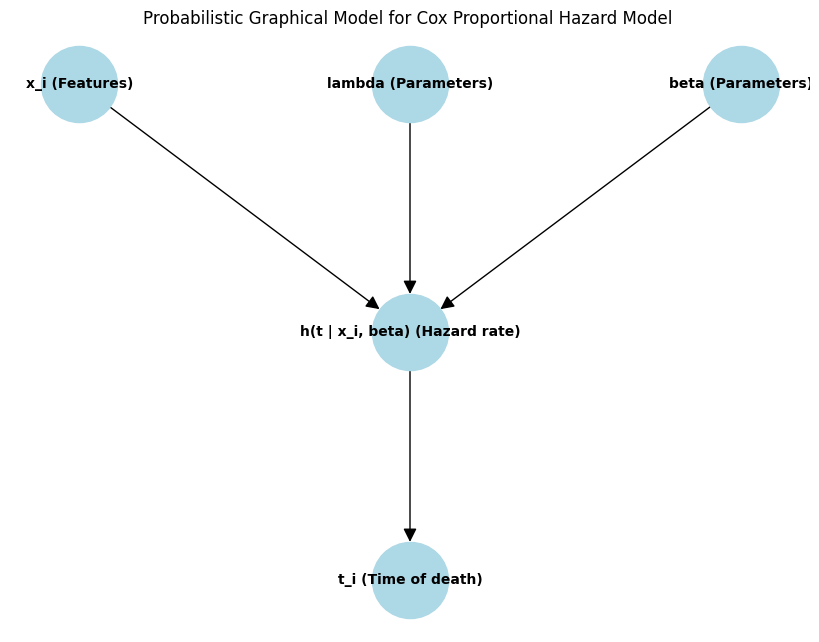

In [8]:

G = nx.DiGraph()

G.add_node("x_i (Features)", pos=(-1, 1))
G.add_node("lambda (Parameters)", pos=(0, 1))
G.add_node("beta (Parameters)", pos=(1, 1))
G.add_node("h(t | x_i, beta) (Hazard rate)", pos=(0, 0))
G.add_node("t_i (Time of death)", pos=(0, -1))

G.add_edge("x_i (Features)", "h(t | x_i, beta) (Hazard rate)")
G.add_edge("lambda (Parameters)", "h(t | x_i, beta) (Hazard rate)")
G.add_edge("beta (Parameters)", "h(t | x_i, beta) (Hazard rate)")
G.add_edge("h(t | x_i, beta) (Hazard rate)", "t_i (Time of death)")

pos = nx.get_node_attributes(G, 'pos')

plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue",
        font_size=10, font_weight="bold", arrowsize=20)
plt.title("Probabilistic Graphical Model for Cox Proportional Hazard Model ")
plt.show()


<div class="alert alert-success">
    
**Q4**. Implement the (conditional) model described above (i.e., the prior, the likelihood, as well as a sampler). For the time being, consider an uninformative prior for the model parameters. 

_Tips_: 
Notice that for our choice of baseline hazard $h_0(t) = \lambda$, the cumulative hazard is $H(t) = \lambda t \exp(\boldsymbol{\beta}^T \mathbf{x}) = \lambda t \, c(\mathbf{x}; \boldsymbol{\beta})$ for $c(\mathbf{x}; \boldsymbol{\beta}) = \exp(\boldsymbol{\beta}^T \mathbf{x})$. Therefore, the probability density function of the survival time is $f(t) = h(t) S(t) = \lambda c(x; \boldsymbol{\beta}) \exp(-\lambda t c(\mathbf{x}; \boldsymbol{\beta}))$, which corresponds to an Exponential distribution with rate $\lambda c(\mathbf{x}; \boldsymbol{\beta})$. 

</div>

In [9]:
def log_prior(theta):
    beta, log_lambda = theta
    lp_beta = norm.logpdf(beta, loc=0, scale=0.5)
    lp_log_lambda = norm.logpdf(log_lambda, loc=0, scale=1)
    
    return lp_beta + lp_log_lambda


def log_likelihood(theta, X, T, E):
    beta, log_lambda = theta
    lambda_ = np.exp(log_lambda)

    linear_term = X * beta
    hazard = lambda_ * np.exp(linear_term)

    log_pdf = np.log(hazard**E * np.exp(-hazard * T))
    return np.sum(log_pdf)


def log_posterior(theta, X, T, E):
    return log_prior(theta) + log_likelihood(theta, X, T, E)



In [10]:
def sample_prior(n_features):
    beta = norm.rvs(loc=0, scale=1, size=n_features)
    lambda_ = beta_dist.rvs(a=1, b=5, scale=0.1)
    return beta, lambda_

<div class="alert alert-success">
    
**Q5**. Using a prior predictive check, evaluate and discuss if the prior predictive distribution is realistic. Propose a weakly informative prior that results in more realistic simulated data.

_Tips_: Plot the survival function $S(t)$ for different parameter samples drawn from the prior.
    
</div>

In [11]:
def sample_prior(n_features):
    beta = norm.rvs(loc= 0.05, scale=0.0001, size=n_features)
    lambda_ = norm.rvs(loc = 0.007, scale =0.003)
    return beta, lambda_


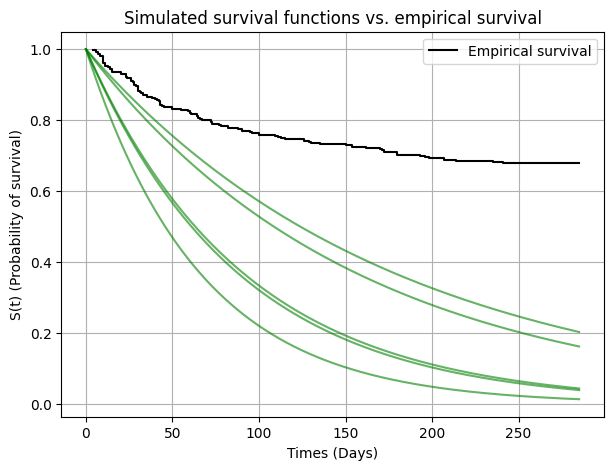

In [12]:
heart_df =pd.read_csv("heart.csv")
T =heart_df["time"].values
E =heart_df["DEATH_EVENT"].values

n_features = heart_df.shape[1] - 2
n_samples = 5
t_grid = np.linspace(0, T.max(), 200)


X_raw = heart_df.drop(columns=["time", "DEATH_EVENT"]).to_numpy()
X = (X_raw - X_raw.min(axis=0))/(X_raw.max(axis=0) - X_raw.min(axis=0))
x_mean = X.mean(axis=0)

def survival_probability(df_sorted):
    n = len(df_sorted)
    survivors = n
    S = np.empty(n, dtype=float)
    for i in range(n):
        if df_sorted["DEATH_EVENT"][i] == 1:
            survivors -= 1
        S[i] = survivors / n
    return S

S_emp = survival_probability(heart_df)

plt.figure(figsize=(7, 5))

plt.step(T, S_emp, where="post", color="black", label="Empirical survival")

for _ in range(n_samples):
    beta, lambda_ = sample_prior(n_features)
    linpred = float(np.dot(x_mean, beta))
    rate = float(lambda_) * np.exp(linpred)
    S_t = np.exp(-rate * t_grid)
    plt.plot(t_grid, S_t, color="green", alpha=0.6)

plt.title("Simulated survival functions vs. empirical survival")
plt.xlabel("Times (Days)")
plt.ylabel("S(t) (Probability of survival)")
plt.grid(True)
plt.legend()
plt.show()


The black curve shows the probability of survival calculated from the data. To construct it, patients are classified according to duration. We start with all patients, then remove those who have died as we go along. At any given moment, the probability of survival is the number of survivors divided by the initial number.

The green curves represent simulated survival using the Cox model and taking different $\beta$ and sigma values.

After several attempts, we can see that $\beta$ has an effect on the slope of the curve. The higher the $\beta$, the faster the curve descends. 
We can interpret this as $\beta$ indicating the effect of the variables studied on an individual's survival. If $\beta$ is large and positive, the risk increases and survival decreases more rapidly, while if $\beta$ is negative, the individual has a better chance of survival. The variable in question has a protective effect. 

Graphically, $\lambda$ rounds the curve when it is relatively smaller than $\beta$. The smaller $\lambda$ is, the more it will resemble a straight line; the larger it is, the closer it is to zero, and the more rounded the curve will be. 
When it is close to the value of $\beta$, it has the effect of accelerating the curve. 

In my opinion, $\lambda$ is the basic risk. A high $\lambda$ leads to a rapid decline in survival, while a low $\lambda$ corresponds to a lower risk and therefore longer survival.

By comparing the curves, we see that the simulations often decrease more rapidly than the actual curve, especially at the beginning. However, it is difficult to adjust the two curves correctly.

# Compute: Posterior inference

<div class="alert alert-success">
    
**Q6a**. Using as input features $\mathbf{x}$ the binary variable `high_blood_pressure`, the death or censoring time `time`, and the event indicator `DEATH_EVENT`, compute the posterior distribution of all unobserved random variables.
    
_Tips_: If you use MCMC, initialize the chain(s) around the MAP estimate.
    
</div>

In [13]:
X = heart_df["high_blood_pressure"].values


def neg_log_post(theta):
    return -log_posterior(theta, X, T, E)

beta_arr, lambda_val = sample_prior(1)
theta_m = np.array([beta_arr[0], np.log(lambda_val)], dtype=float)

res = minimize(neg_log_post, theta_m, bounds=[[None, None], [None, None]])
res


  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 690.0327826947184
        x: [ 3.332e-01 -6.055e+00]
      nit: 8
      jac: [ 0.000e+00 -1.137e-05]
     nfev: 27
     njev: 9
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

In [14]:
theta_map = res.x
print("MAP estimate:")
print("beta =", round(theta_map[0], 4))
print("lambda =", round(np.exp(theta_map[1]), 4))

ndim = 2
nwalkers = 20
nsteps = 5000
init_pos = theta_map + 0.5*np.random.randn(nwalkers, ndim)

samplera = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(X, T, E))
samplera.run_mcmc(init_pos, nsteps, progress=True);

MAP estimate:
beta = 0.3332
lambda = 0.0023


100%|██████████| 5000/5000 [00:11<00:00, 421.92it/s]


<div class="alert alert-success">
    
**Q7a**. Assess whether your inference results are computationally faithful (check the convergence, mixing, and autocorrelation of the chains).
    
</div>

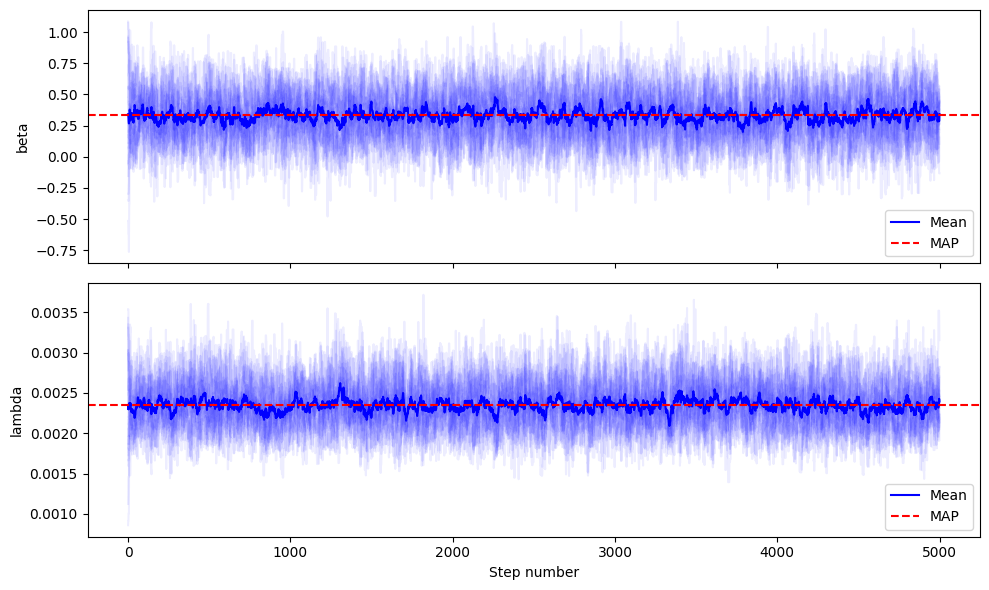

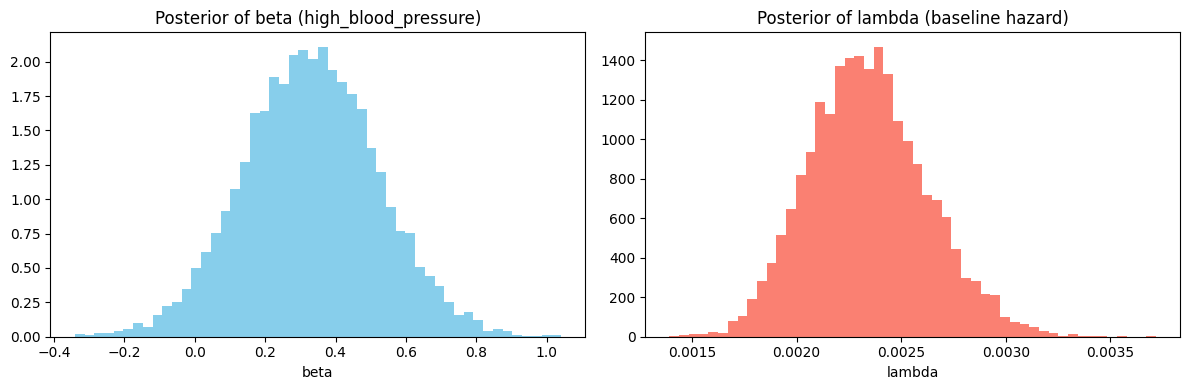

Temps d'autocorrélation pour chaque paramètre : [28.60693735 32.16461021]
Nombre d'échantillons indépendants : [174.7827787  155.45035263]


In [15]:
param_names = ["beta", "lambda"]
samples_raw = samplera.get_chain()

nsteps, nwalkers, ndim = samples_raw.shape


samples_lambda = np.empty_like(samples_raw)
samples_lambda[:, :, 0] = samples_raw[:, :, 0] 
samples_lambda[:, :, 1] = np.exp(samples_raw[:, :, 1])

theta_map_real = [theta_map[0], np.exp(theta_map[1])]

fig, axes = plt.subplots(ndim, figsize=(10, 6), sharex=True)
for i in range(ndim):
    for w in range(nwalkers):
        axes[i].plot(samples_lambda[:, w, i], color="blue", alpha=0.07)
    mean_chain = np.mean(samples_lambda[:, :, i], axis=1)
    axes[i].plot(mean_chain, color='blue', label='Mean', alpha=1)
    axes[i].axhline(theta_map_real[i], color="red", linestyle="--", label="MAP")
    axes[i].set_ylabel(param_names[i])
    axes[i].legend()

axes[-1].set_xlabel("Step number")
plt.tight_layout()
plt.show()


samples_flat_hbp = samplera.get_chain(discard = 500,thin= 12,flat=True)


samples_lambda = samples_flat_hbp.copy()
samples_lambda[:, 1] = np.exp(samples_lambda[:, 1])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(samples_lambda[:, 0], bins=50, density=True, color="skyblue")
plt.title("Posterior of beta (high_blood_pressure)")
plt.xlabel("beta")

plt.subplot(1, 2, 2)
plt.hist(samples_lambda[:, 1], bins=50, density=True, color="salmon")
plt.title("Posterior of lambda (baseline hazard)")
plt.xlabel("lambda")

plt.tight_layout()
plt.show()


try:
    tau = samplera.get_autocorr_time()
    print(f"Temps d'autocorrélation pour chaque paramètre : {tau}")
    print(f"Nombre d'échantillons indépendants : {nsteps / tau}")
except Exception as e:
    print(f"Erreur lors du calcul du temps d'autocorrélation : {e}")


Using the estimated value of $\beta$ of approximately 0.33 (MAP) and calculating the average of all walkers, we can see that the McMc has converged well around the estimated MAP value (red line). Since we have a positive value, this suggests that `high_blood_pressure` has a positive effect on risk in the Cox model, i.e., it increases the probability of death as explained in the first part of the assignment.
We observe the same type of result with $\lambda$ estimated at approximately 0.0023, which is also centred around its MAP estimate.


<div class="alert alert-success">
    
**Q8a**. Plot the posterior distributions and discuss the results.
    
</div>

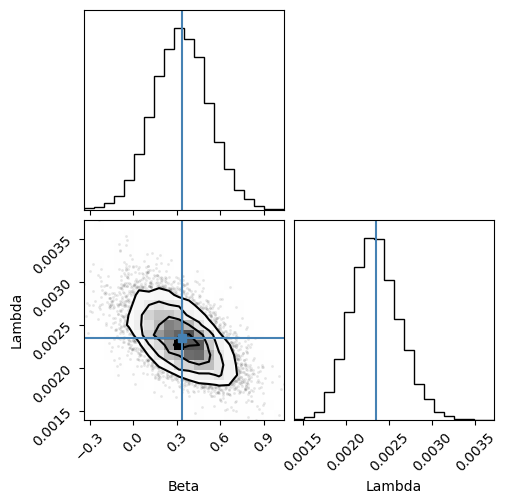

In [16]:
fig = corner.corner(samples_lambda, labels=['Beta' ,'Lambda'],truths=[theta_map[0], np.exp(theta_map[1])])

The scatter plot highlights a negative relationship between $\beta$ and $\lambda$. When Beta increases, Lambda tends to decrease, and vice versa.

Furthermore, we can see that this scatter plot and the histogram are centred around the value estimated by the map (in blue), which seems to confirm our observations from the previous question.

<div class="alert alert-success">
    
**Q6b, Q7b, Q8b**. Repeat the above steps using instead the binary variable `smoking` as input feature.
    
</div>

In [17]:
X = heart_df["smoking"].values


beta_arr, lambda_val = sample_prior(1)
theta_m = np.array([beta_arr[0], lambda_val], dtype=float)


res = minimize(neg_log_post, theta_m, bounds=[[None, None], [None, None]])
res

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 691.4531687596036
        x: [-8.099e-02 -5.921e+00]
      nit: 16
      jac: [ 2.501e-04 -3.524e-04]
     nfev: 51
     njev: 17
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

MAP estimate:
beta = -0.081
lambda = 0.0027


100%|██████████| 5000/5000 [00:12<00:00, 416.58it/s]


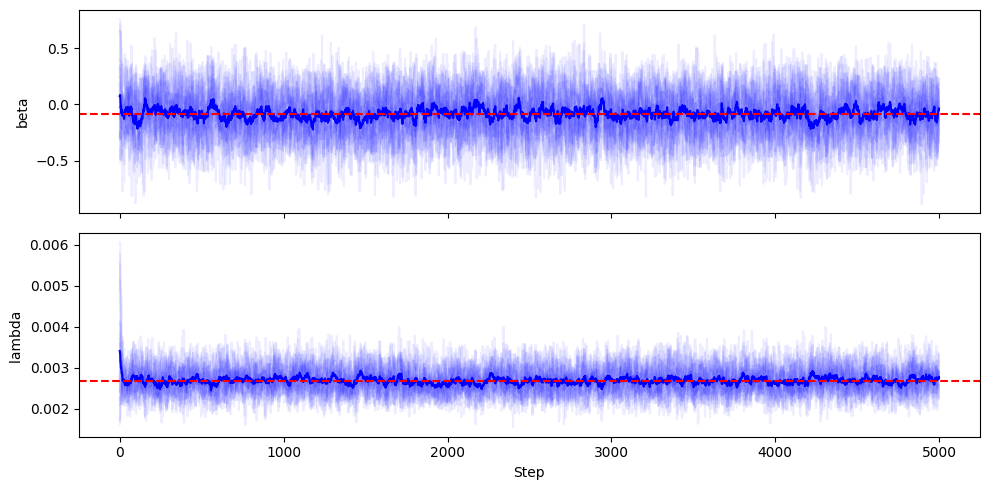

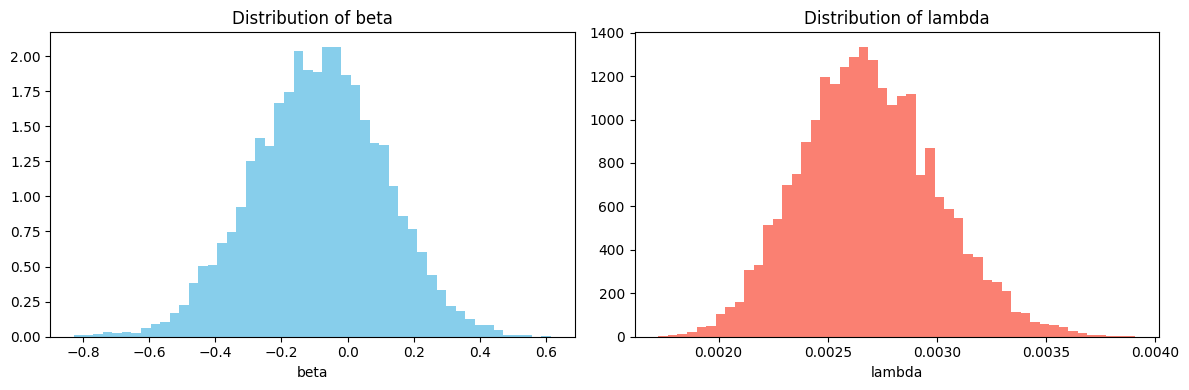

Temps d'autocorrélation pour chaque paramètre : [29.19553419 30.2428287 ]
Nombre d'échantillons indépendants : [171.25906886 165.32845023]


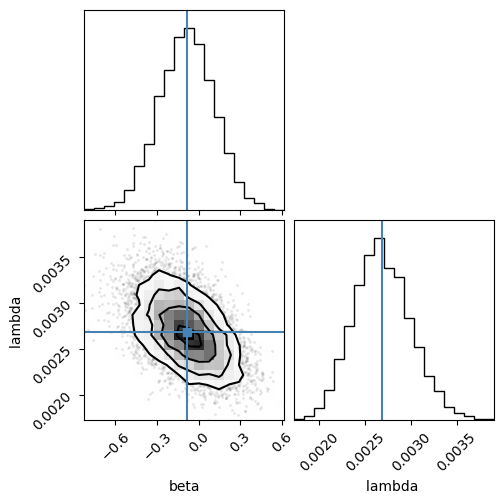

In [18]:
theta_map = res.x
print("MAP estimate:")
print("beta =", round(theta_map[0], 4))
print("lambda =", round(np.exp(theta_map[1]), 4))


init_pos = theta_map + 0.5 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(X, T, E))
sampler.run_mcmc(init_pos, nsteps, progress=True);

samples_smk = sampler.get_chain(flat=False)
nsteps, nwalkers, ndim = samples_smk.shape
param_names = ["beta", "lambda "]

samples_smk_transformed = samples_smk.copy()
samples_smk_transformed[:, :, 1] = np.exp(samples_smk[:, :, 1])

fig, axes = plt.subplots(ndim, figsize=(10, 5), sharex=True)
for i in range(ndim):
    for w in range(nwalkers):
        axes[i].plot(samples_smk_transformed[:, w, i], color="blue", alpha=0.07)
    mean_chain = np.mean(samples_smk_transformed[:, :, i], axis=1)
    axes[i].plot(mean_chain, color='blue', label='Mean', alpha=1)
    map_val = theta_map[i] if i == 0 else np.exp(theta_map[i])
    axes[i].axhline(map_val, color="red", linestyle="--", label="MAP")
    axes[i].set_ylabel(param_names[i])
axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()




flat_samples_smk = sampler.get_chain(discard= 500, thin = 12, flat=True)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(flat_samples_smk[:, 0], bins=50, density=True, color="skyblue")
plt.title("Distribution of beta")
plt.xlabel("beta")

plt.subplot(1, 2, 2)
plt.hist(np.exp(flat_samples_smk[:, 1]), bins=50, density=True, color="salmon")
plt.title("Distribution of lambda")
plt.xlabel("lambda")

plt.tight_layout()
plt.show()

try:
    tau = sampler.get_autocorr_time()
    print(f"Temps d'autocorrélation pour chaque paramètre : {tau}")
    print(f"Nombre d'échantillons indépendants : {nsteps / tau}")
except Exception as e:
    print(f"Erreur lors du calcul du temps d'autocorrélation : {e}")

flat_transformed = flat_samples_smk.copy()
flat_transformed[:, 1] = np.exp(flat_transformed[:, 1])
fig = corner.corner(flat_transformed, labels=param_names,truths=[theta_map[0], np.exp(theta_map[1])])
plt.show()

Applying the same method as before, we obtain an estimated value of $\beta$ of approximately -0.081 (MAP) and, by calculating the mean of all walkers (dark blue), we can see that the McMc has converged well around the estimated MAP value (red line). As we have $\beta$ centred slightly below zero. This suggests that the effect of smoking on risk is not clearly negative in a marked way, but that there is a slight tendency towards risk reduction, which may be a little strange given the negative effect of smoking on health. However, given the negative correlation in the correlation matrix in the first part, this result was somewhat predictable for this dataset.

We observe the same type of result with $\lambda$ estimated at around 0.0027, which is also centred around its MAP estimate.

Regarding the corner plot, we observe the same results as before.
The scatter plot highlights a negative relationship between $\beta$ and $\lambda$. When Beta increases, Lambda tends to decrease, and vice versa.

Furthermore, we can see that this scatter plot and the histogram are centred around the value estimated by the MAP (in blue). 

# Criticize

<div class="alert alert-success">
    
**Q9**. Evaluate the posterior predictive distribution for the two models and discuss the results.

_Tips_: Plot the survival function $S(t)$ for different parameter samples drawn from the posterior against the empirical survival function of the observed data $\hat{S}(t) = \frac{N(t)}{N}$, where $N(t)$ is the number of patients who survived beyond time $t$.
    
</div>

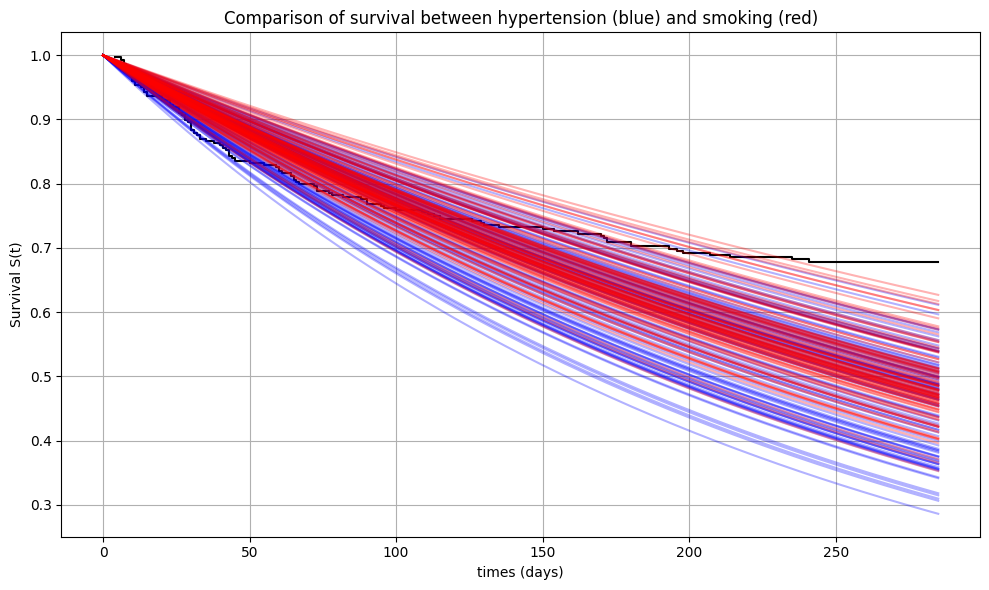

In [19]:
x_hbp = heart_df["high_blood_pressure"].mean()
x_smoke = heart_df["smoking"].mean()

t_vals = np.linspace(0, T.max(), 200)

plt.figure(figsize=(10, 6))
plt.step(T, S_emp, where="post", color="black", label="Empirical survival (manual)")


for idx in np.random.choice(len(samples_flat_hbp), size=50, replace=False):
    beta, log_lambda = samples_flat_hbp[idx]
    lambda_ = np.exp(log_lambda)
    S = np.exp(-lambda_ * t_vals * np.exp(beta * 0))
    S1 = np.exp(-lambda_ * t_vals * np.exp(beta * 1))
    plt.plot(t_vals, S, color="blue", alpha=0.3, label="high_blood_pressure")
    plt.plot(t_vals, S1, color="blue", alpha=0.3, label="high_blood_pressure")

for idx in np.random.choice(len(flat_samples_smk), size=50, replace=False):
    beta, log_lambda = flat_samples_smk[idx]
    lambda_ = np.exp(log_lambda)
    S = np.exp(-lambda_ * t_vals * np.exp(beta * 0))
    S1 = np.exp(-lambda_ * t_vals * np.exp(beta * 1))
    plt.plot(t_vals, S, color="red", alpha=0.3, label="smoking")
    plt.plot(t_vals, S1, color="red", alpha=0.3, label="smoking")

plt.title("Comparison of survival between hypertension (blue) and smoking (red)")
plt.xlabel("times (days)")
plt.ylabel("Survival S(t)")
plt.grid(True)
plt.tight_layout()
plt.show()


The black curve corresponds to the empirical survival calculated from actual data in the same way as in the first part.

In the first plot, we calculate the average of people suffering from `high_blood_pressure` and people who `smoking`. We then apply the Cox model to these variables to see the general trend between our two models. The blue curves represent the survival functions predicted from `high_blood_pressure`, while the red curves correspond to the model using the `smoking` variable.

We can see that, in general, the curves calculated from the average of `smoking` are slightly more compact and slightly higher than those calculated from `high_blood_pressure`. 
We can see the difference between a positive and negative beta, although it is very small and therefore we cannot see such a big difference in survival between the two models. 

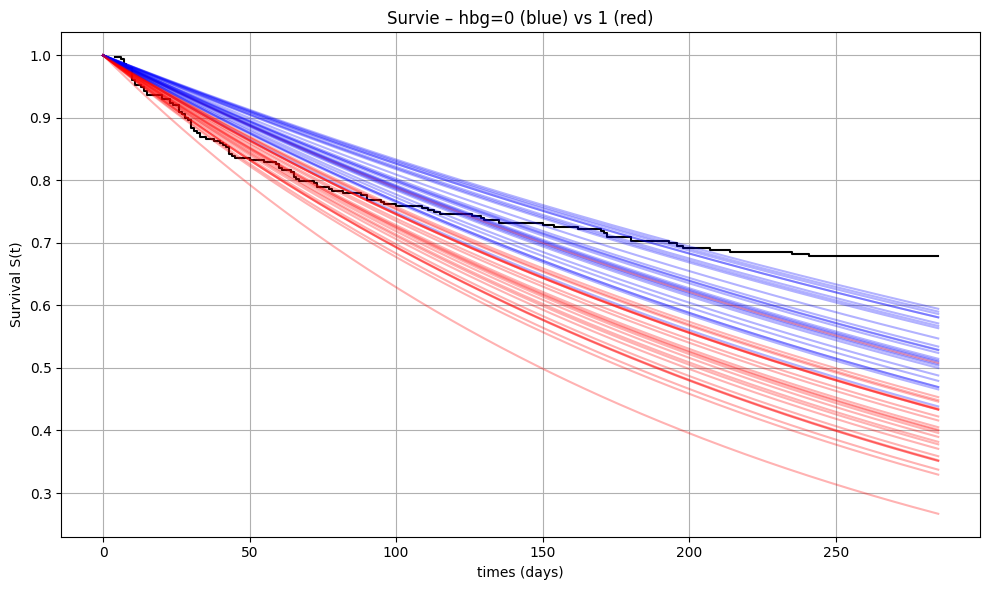

In [20]:
plt.figure(figsize=(10, 6))
plt.step(T, S_emp, where="post", color="black", label="Empirical survival (manual)")


for idx in np.random.choice(len(samples_flat_hbp), size=25, replace=False):
    beta, loglam = samples_flat_hbp[idx]
    lam = np.exp(loglam)
    S0 = np.exp(-lam * t_vals * np.exp(beta * 0))
    S1 = np.exp(-lam * t_vals * np.exp(beta * 1))
    plt.plot(t_vals, S0, color="blue", alpha=0.3, label=None)
    plt.plot(t_vals, S1, color="red", alpha=0.3, label=None)

plt.title("Survie – hbg=0 (blue) vs 1 (red)")
plt.xlabel("times (days)")
plt.ylabel("Survival S(t)")
plt.grid(True)
plt.tight_layout()
plt.show()


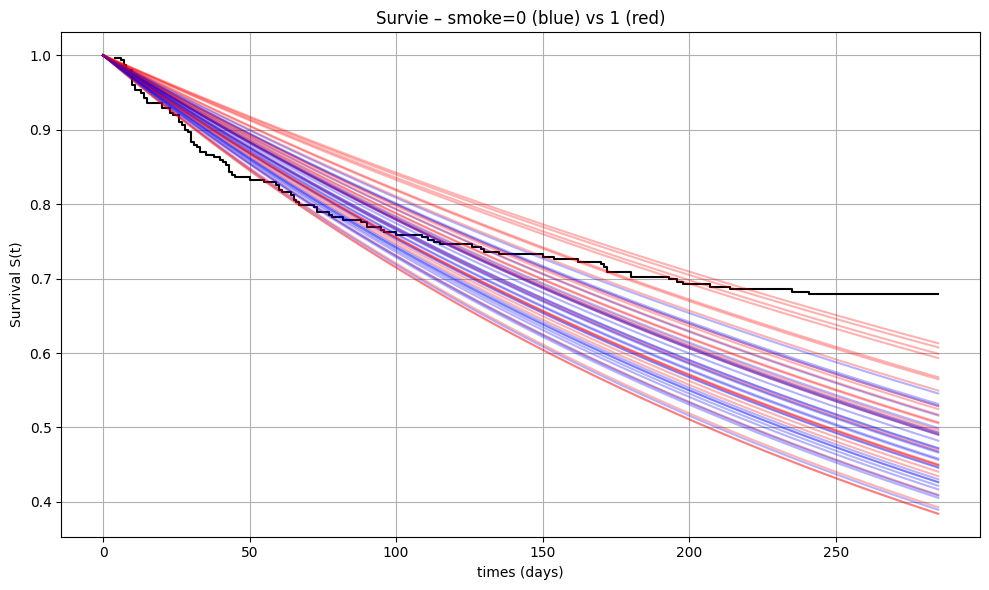

In [21]:


plt.figure(figsize=(10, 6))
plt.step(T, S_emp, where="post", color="black", label="Empirical survival (manual)")

for idx in np.random.choice(len(flat_samples_smk), size=25, replace=False):
    beta, loglam = flat_samples_smk[idx]
    lam = np.exp(loglam)
    S0 = np.exp(-lam * t_vals * np.exp(beta * 0))
    S1 = np.exp(-lam * t_vals * np.exp(beta * 1))
    plt.plot(t_vals, S0, color="blue", alpha=0.3, label=None)
    plt.plot(t_vals, S1, color="red", alpha=0.3, label=None)

plt.title("Survie – smoke=0 (blue) vs 1 (red)")
plt.xlabel("times (days)")
plt.ylabel("Survival S(t)")
plt.grid(True)
plt.tight_layout()
plt.show()


When we compare each variable independently of one another and focus on the binary nature of the variable in question. 

Therefore, we then notice the difference in survival chances between people who have a problem with `high_blood_pressure`, where we see a clear difference between those who `smoking` and those who do not. This is due to the beta, which is greater in absolute value and shows the importance of the variable for a person's chance of survival in this dataset.

<div class="alert alert-success">
    
**Q10**. Evaluate the posterior predictive distributions of test quantities of replicated data and discuss the results.
    
</div>

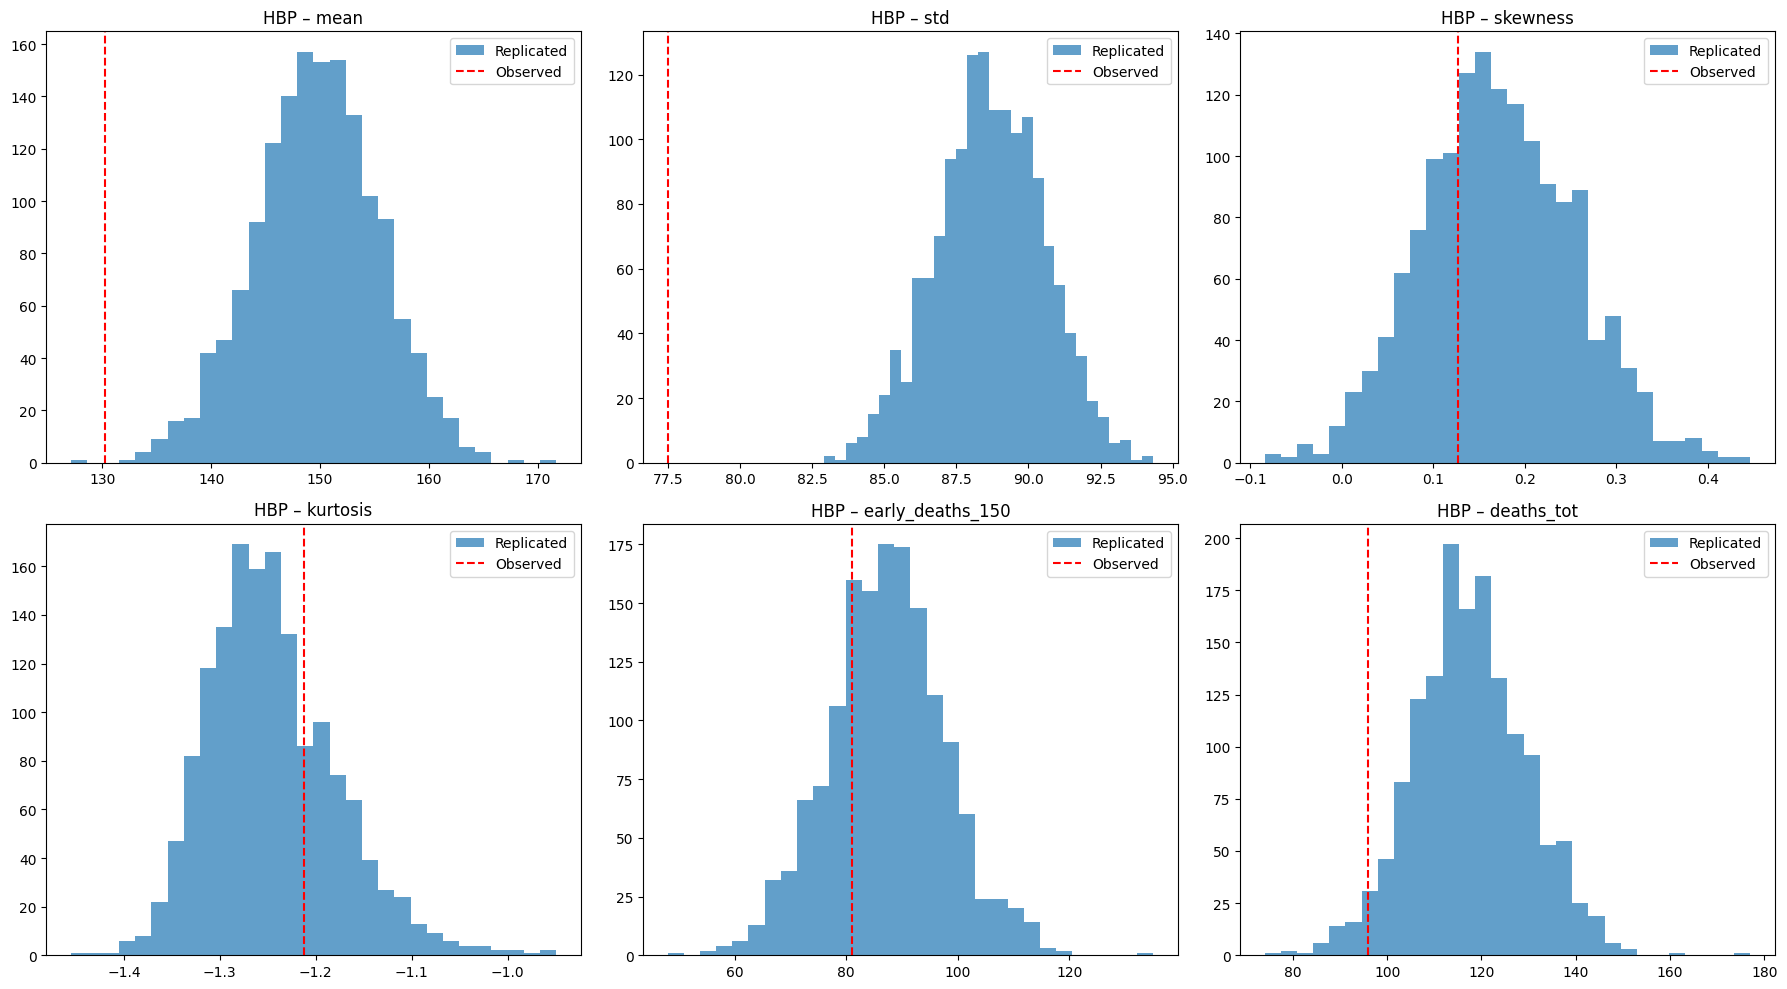

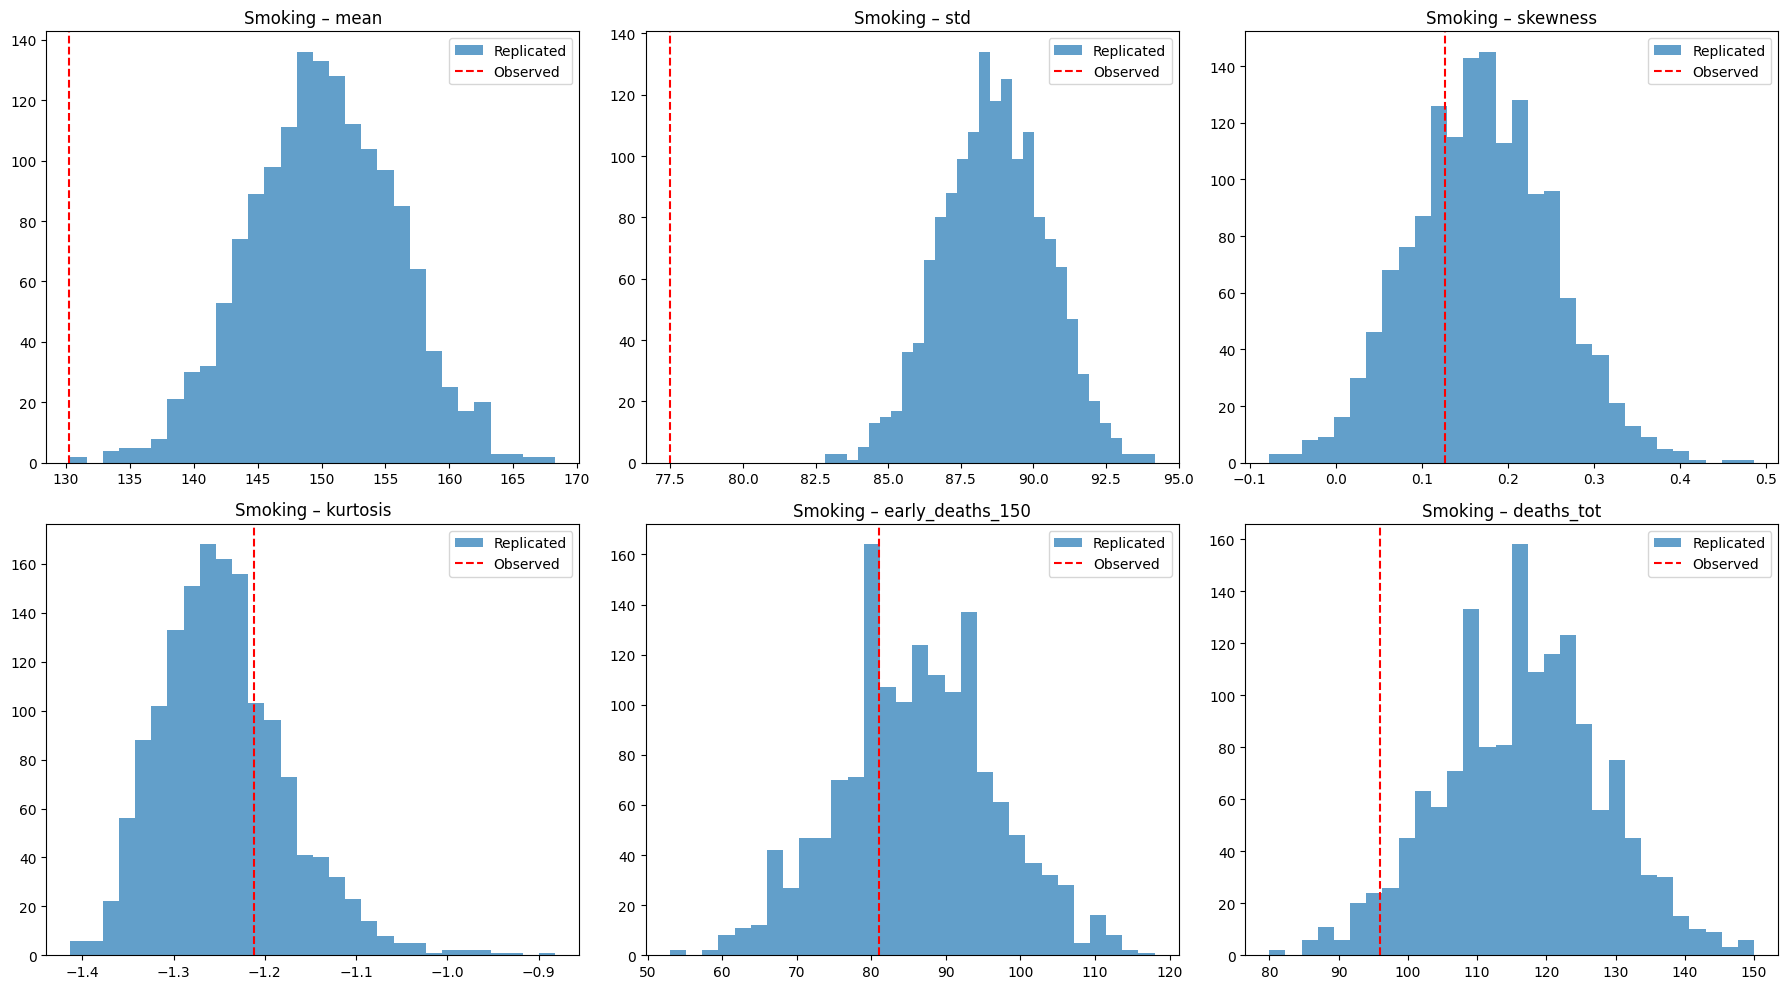

In [22]:
X_hbp = heart_df["high_blood_pressure"].to_numpy()
X_smoke = heart_df["smoking"].to_numpy()

T_obs = heart_df["time"].to_numpy()
delta_obs = heart_df["DEATH_EVENT"].to_numpy()

C_ind = np.where(delta_obs == 0, T_obs, np.inf)
C_admin = T_obs.max()
C_total = np.minimum(C_ind, C_admin)

flat_samples_bp = np.asarray(samples_flat_hbp).reshape(-1, samples_flat_hbp.shape[-1])
flat_samples_smoke = np.asarray(samples_smk).reshape(-1, samples_smk.shape[-1])

rng = np.random.default_rng(42)

def simulate_rep_once(post_samples, X_vec, C_vec, rng):
    idx = rng.integers(0, post_samples.shape[0])
    beta, loglam = post_samples[idx]
    lam = np.exp(loglam)
    rate = lam * np.exp(beta * X_vec)
    T_true = rng.exponential(scale=1.0 / rate, size=X_vec.shape[0])
    Y_rep = np.minimum(T_true, C_vec)
    Delta_rep = (T_true <= C_vec).astype(int)
    return Y_rep, Delta_rep

def calc_test_quantities(y, d, t0=150):
    return {
        "mean": np.mean(y),
        "std": np.std(y),
        "skewness": skew(y),
        "kurtosis": kurtosis(y),
        "early_deaths_150": np.sum((y <= t0) & (d == 1)),
        "deaths_tot": np.sum(d)
    }

#HBP
n_replicates = 1500
replicated_quantities_hbp = []
for _ in range(n_replicates):
    y_rep, d_rep = simulate_rep_once(flat_samples_bp, X_hbp, C_total, rng)
    replicated_quantities_hbp.append(calc_test_quantities(y_rep, d_rep))

observed_quantities_hbp = calc_test_quantities(T_obs, delta_obs)

#Smoking
replicated_quantities_smoke = []
for _ in range(n_replicates):
    y_rep, d_rep = simulate_rep_once(flat_samples_smoke, X_smoke, C_total, rng)
    replicated_quantities_smoke.append(calc_test_quantities(y_rep, d_rep))

observed_quantities_smoke = calc_test_quantities(T_obs, delta_obs)

#Plots 
metrics = ["mean", "std", "skewness", "kurtosis", "early_deaths_150", "deaths_tot"]

# HBP
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for i, metric in enumerate(metrics):
    values = [q[metric] for q in replicated_quantities_hbp]
    ax = axes[i]
    ax.hist(values, bins=30, alpha=0.7, label="Replicated")
    ax.axvline(observed_quantities_hbp[metric], color="red", linestyle="--", label="Observed")
    ax.set_title(f"HBP – {metric}")
    ax.legend()
for j in range(i+1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

# Smoking
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for i, metric in enumerate(metrics):
    values = [q[metric] for q in replicated_quantities_smoke]
    ax = axes[i]
    ax.hist(values, bins=30, alpha=0.7, label="Replicated")
    ax.axvline(observed_quantities_smoke[metric], color="red", linestyle="--", label="Observed")
    ax.set_title(f"Smoking – {metric}")
    ax.legend()
for j in range(i+1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()



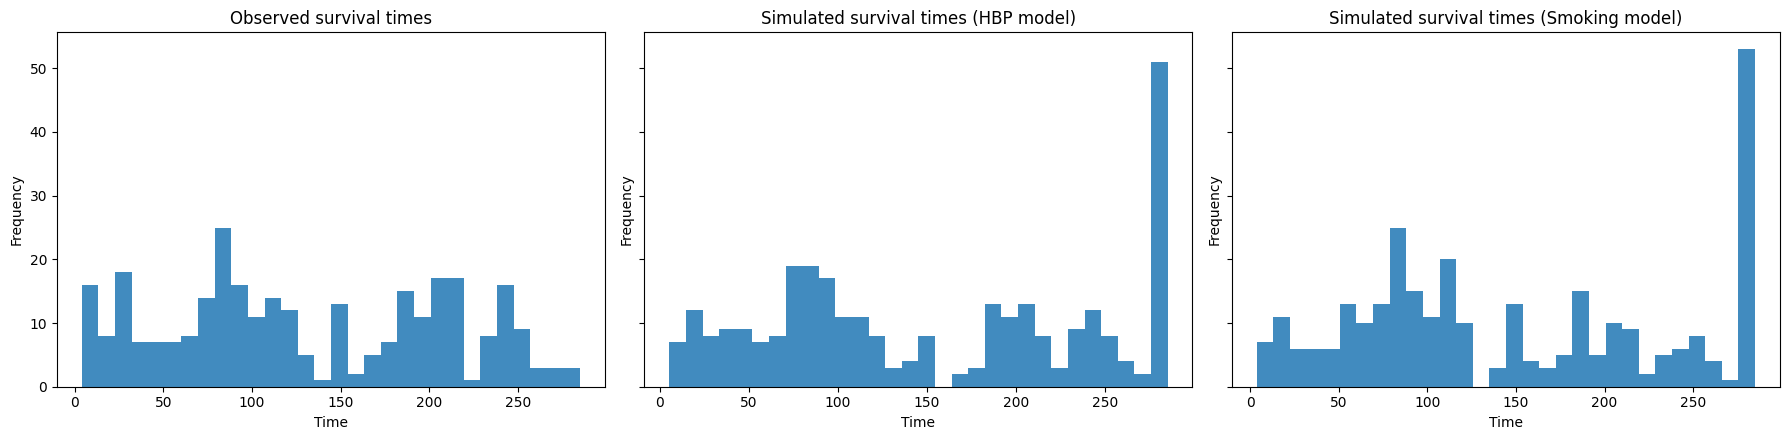

In [23]:
def simulate_one_dataset(post_samples, X_vec, C_vec, rng):
    idx = rng.integers(0, post_samples.shape[0])
    beta, loglam = post_samples[idx]
    lam = np.exp(loglam)
    rate = lam * np.exp(beta * X_vec)
    T_true = rng.exponential(scale=1.0 / rate, size=X_vec.shape[0])
    Y_rep = np.minimum(T_true, C_vec)
    return Y_rep

y_rep_hbp = simulate_one_dataset(flat_samples_bp, X_hbp, C_total, rng)
y_rep_smk = simulate_one_dataset(flat_samples_smoke, X_smoke, C_total, rng)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)

axes[0].hist(T_obs, bins=30, alpha=0.85)
axes[0].set_title("Observed survival times")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Frequency")

axes[1].hist(y_rep_hbp, bins=30, alpha=0.85)
axes[1].set_title("Simulated survival times (HBP model)")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Frequency")

axes[2].hist(y_rep_smk, bins=30, alpha=0.85)
axes[2].set_title("Simulated survival times (Smoking model)")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


These graphs compare, for each statistic (mean, standard deviation, skewness, kurtosis, number of early deaths and up to the maximum observation period), the distribution obtained from the data simulated by the models (blue histograms) and the value observed in the actual data (red line).
Overall, we can see that the two models generally produce the same results. 

For the mean, we observe that both models tend to overestimate the time, as the mean distributions are relatively far to the right of the observed values. The peak of the distributions is approximately 20 days away from the actual values. This is confirmed by the standard deviation graphs for both models, which show very similar results.

In terms of the distribution of models and actual observations, we can see that the distributions are broadly similar. However, with regard to the models, there is a peak at the 250-day mark because we apply a censor to avoid retaining values that are too large and exceed the observations in the dataset. This censoring is applied because it is possible for a person to have a shorter time but not necessarily to have died. It is simply a case of stopping observations on a patient. 
Regarding the symmetry of the distributions, we can see that they are all relatively similar, as can be seen in the skewness graph, but our predictions are slightly higher due to the extreme values. Regarding extreme values, we can see with kurtosis that we have higher extreme values compared to a normal distribution. Given the kurtosis values, this is the case for all three distributions, but it is more pronounced for the model predictions due to the censoring of extreme values.

Regarding the results for deaths before 150 days of observation, the models are much better at predicting whether a patient has died within this relatively short period of time. However, the model with the variable `smoking` is more accurate in terms of the observed values compared to the model with `high_blood_pressure`. When we look at the total number of deaths before the last observation in the dataset, we can see that both models tend to be pessimistic about patient survival. 

In summary, these graphs show that the model struggles to accurately reproduce the average duration and dispersion of survival times, but performs better at describing the overall shape of the distribution. As for the number of early deaths (<150), we are able to better reflect reality compared to the entire time interval of the dataset. This is consistent with the observations we had for the previous question, where we are able to follow the survival curve relatively well up to 150 days, after which we are much more pessimistic.



<div class="alert alert-success">
    
**Q11**. Evaluate the posterior predictive performance of both models and discuss the results.

</div>

In [ ]:
def logscore(draws, x, t, d):
    beta = draws[:, 0][:, None]
    lam = np.exp(draws[:, 1])[:, None]
    rate = lam * np.exp(beta * x[None, :])
    logL = (d[None, :] * np.log(rate)) - rate * t[None, :]
    return np.log(np.mean(np.exp(logL), axis=0))

logscore_hbp = float(np.sum(logscore(flat_samples_bp, X_hbp, T_obs, delta_obs)))
logscore_smk = float(np.sum(logscore(flat_samples_smoke, X_smoke, T_obs, delta_obs)))

print(f"LogScore (HBP) = {logscore_hbp:.3f}")
print(f"LogScore (Smoking) = {logscore_smk:.3f}")


LogScore (HBP) = -670.220
LogScore (Smoking) = -672.668


Based on the logScore, the `high_blood_pressure` model slightly better reflects the values observed in the dataset we have.

# Revise

<div class="alert alert-success">
    
**Q12**. Explain and motivate what could be tried to further improve the probabilistic model considered in this study. (No implementation is required.)

</div>

It may be that the model is based on only one binary variable, which is insufficient to explain the durations. The next step is to add clinical variables available in the dataset (age, ejection fraction, sodium, creatinine, CPK, anaemia, diabetes, gender, etc.). The idea is to focus on risk factors that show a better correlation with survival time.